# Mechanistic Drives: Hunger

This notebook explains the hunger drive as the simplest mechanistic basis for adaptive behavior in AXIS CMS.

Primary focus:
- homeostasis and energy
- hunger activation
- resource-based action scoring
- System A as the baseline architecture
- why this is still reactive control rather than planning

The running example is `system_a-baseline`, using a manually inspected workspace run rather than a formal experiment series.


In [11]:
from _bootstrap import setup_notebook

ROOT = setup_notebook()


## Why Start With Hunger?

If AXIS is trying to understand how adaptive behavior can emerge from explicit mechanisms, then a good starting point is the smallest mechanism that can already produce meaningful behavioral pressure.

For System A, that mechanism is **hunger**.

The important idea is not that hunger is psychologically rich. It is that hunger is a minimal example of a **homeostatic control variable**:

- the system has an internal scalar state: energy
- deviations from a preferred regime create pressure
- that pressure modulates action tendencies using only local sensory input

This gives us a baseline form of adaptive behavior that is mechanistic, interpretable, and mathematically compact.


## Homeostasis In This Notebook

AXIS uses the term *homeostasis* in a narrow and explicit sense.

The system does not represent goals symbolically. It does not search over future world states. It does not compute a plan. Instead, it maintains an energy variable whose depletion directly reshapes current action preferences.

That means the hunger drive is best read as:

> a scalar homeostatic pressure that converts internal deficit into local action bias.

This is already enough to produce structured behavior, but it is still far from planning.


## Mathematical Form

For System A, hunger activation is:

$$
 d_H(t) = \operatorname{clamp}(1 - E_t / E_{\max}, 0, 1)
$$

This immediately gives a simple interpretation:

- when energy is full, hunger activation is `0`
- when energy is empty, hunger activation is `1`
- between those extremes, hunger rises linearly as energy falls

The action contributions are then:

| Action | Formula | Interpretation |
| --- | --- | --- |
| `up`, `down`, `left`, `right` | `phi_H(dir) = d_H * r_dir` | move preference follows resource intensity in that direction |
| `consume` | `phi_H(consume) = d_H * w_consume * r_current` | current-cell resource becomes attractive when hungry |
| `stay` | `phi_H(stay) = -lambda_stay * d_H` | staying is penalized more as hunger rises |

This is important: hunger does **not** directly choose an action. It produces a vector of action tendencies that the policy later turns into a concrete action.


In [12]:
import json
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Markdown, display

from research.lib.plotting import bar_plot, line_plot
from axis.systems.construction_kit.drives.hunger import HungerDrive
from axis.systems.construction_kit.memory.types import ObservationBuffer
from axis.systems.construction_kit.observation.types import CellObservation, Observation
from axis.systems.system_a.types import AgentState

WORKSPACE = ROOT / 'research' / 'workspaces' / 'system_a-baseline'
CONFIG_PATH = WORKSPACE / 'configs' / 'system_a-baseline.yaml'
WORKSPACE_META_PATH = WORKSPACE / 'workspace.yaml'
RUN_SUMMARY_LOG_PATH = WORKSPACE / 'measurements' / 'run_summary.log'

config_data = yaml.safe_load(CONFIG_PATH.read_text())
workspace_meta = yaml.safe_load(WORKSPACE_META_PATH.read_text())
run_summary_log = RUN_SUMMARY_LOG_PATH.read_text(encoding='utf-8')

primary_result = workspace_meta['primary_results'][0]
EXPERIMENT_ID = Path(primary_result['path']).name
RUN_ID = primary_result['primary_run_id']
RESULT_ROOT = WORKSPACE / primary_result['path'] / 'runs' / RUN_ID
RUN_SUMMARY_JSON_PATH = RESULT_ROOT / 'run_summary.json'
BEHAVIOR_METRICS_PATH = RESULT_ROOT / 'behavior_metrics.json'
EPISODES_DIR = RESULT_ROOT / 'episodes'
EPISODE_PATH = EPISODES_DIR / 'episode_0001.json'

summary_metrics = json.loads(RUN_SUMMARY_JSON_PATH.read_text())
behavior_artifact = json.loads(BEHAVIOR_METRICS_PATH.read_text())
behavior_metrics = {
    key: value['mean'] if isinstance(value, dict) and 'mean' in value else value
    for key, value in behavior_artifact['standard_metrics'].items()
    if key not in {'mean_steps', 'death_rate', 'mean_final_vitality'}
}
episode = json.loads(EPISODE_PATH.read_text())

system_cfg = config_data['system']
hunger_drive = HungerDrive(
    consume_weight=system_cfg['policy']['consume_weight'],
    stay_suppression=system_cfg['policy']['stay_suppression'],
    max_energy=system_cfg['agent']['max_energy'],
)

print('Workspace:', WORKSPACE)
print('Config:', CONFIG_PATH.relative_to(ROOT))
print('Workspace metadata:', WORKSPACE_META_PATH.relative_to(ROOT))
print('Run summary log:', RUN_SUMMARY_LOG_PATH.relative_to(ROOT))
print('Experiment ID:', EXPERIMENT_ID)
print('Run ID:', RUN_ID)
print('Representative trace:', EPISODE_PATH.relative_to(ROOT))

Workspace: /workspaces/axis-system-cms/research/workspaces/system_a-baseline
Config: research/workspaces/system_a-baseline/configs/system_a-baseline.yaml
Workspace metadata: research/workspaces/system_a-baseline/workspace.yaml
Run summary log: research/workspaces/system_a-baseline/measurements/run_summary.log
Experiment ID: 212fb5638cc7498db40e3b94eb4ccaf1
Run ID: run-0000
Representative trace: research/workspaces/system_a-baseline/results/212fb5638cc7498db40e3b94eb4ccaf1/runs/run-0000/episodes/episode_0001.json


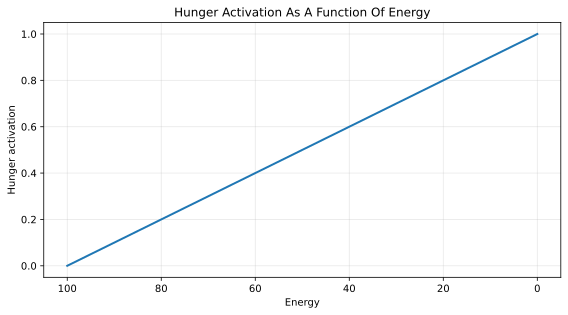

In [13]:
max_energy = system_cfg['agent']['max_energy']
energy_values = list(range(0, int(max_energy) + 1, 5))
hunger_values = [max(0.0, min(1.0, 1.0 - energy / max_energy)) for energy in energy_values]

fig, ax = line_plot(
    energy_values,
    hunger_values,
    title='Hunger Activation As A Function Of Energy',
    xlabel='Energy',
    ylabel='Hunger activation',
)
ax.invert_xaxis()


The inversion of the x-axis is intentional: as available energy falls, hunger pressure rises. This makes the homeostatic reading visually immediate.


## From Energy To Action Tendencies

The next question is where the behavioral structure actually comes from.

Hunger activation alone does not tell the system where to move. The structure appears only when activation is multiplied by **local resource observations**. That is why the drive remains reactive and local:

- internal state supplies pressure
- current observation supplies directional content
- the result is an action-score vector, not a plan

To make that concrete, the next cell uses the actual `HungerDrive.compute(...)` implementation on three contrastive observation cases.


In [14]:
def make_observation(*, current=0.0, up=0.0, down=0.0, left=0.0, right=0.0,
                     current_trav=1.0, up_trav=1.0, down_trav=1.0, left_trav=1.0, right_trav=1.0):
    return Observation(
        current=CellObservation(traversability=current_trav, resource=current),
        up=CellObservation(traversability=up_trav, resource=up),
        down=CellObservation(traversability=down_trav, resource=down),
        left=CellObservation(traversability=left_trav, resource=left),
        right=CellObservation(traversability=right_trav, resource=right),
    )


def make_state(energy: float) -> AgentState:
    return AgentState(
        energy=energy,
        observation_buffer=ObservationBuffer(entries=(), capacity=system_cfg['agent']['buffer_capacity']),
    )


cases = [
    {
        'case': 'A: full energy, no local resource signal',
        'energy': 100.0,
        'observation': make_observation(current=0.0, up=0.0, down=0.0, left=0.0, right=0.0, down_trav=0.0),
    },
    {
        'case': 'B: moderate hunger, resource in one neighbor',
        'energy': 60.0,
        'observation': make_observation(current=0.0, up=0.0, down=0.0, left=0.0, right=0.8),
    },
    {
        'case': 'C: strong hunger, resource on current cell',
        'energy': 35.0,
        'observation': make_observation(current=0.65, up=0.0, down=0.0, left=0.0, right=0.0, up_trav=0.0, right_trav=0.0),
    },
]

case_rows = []
case_score_rows = []
action_names = ['up', 'down', 'left', 'right', 'consume', 'stay']
for case in cases:
    result = hunger_drive.compute(make_state(case['energy']), case['observation'])
    case_rows.append(
        {
            'case': case['case'],
            'energy': case['energy'],
            'hunger_activation': result.activation,
            'current_resource': case['observation'].current.resource,
            'up_resource': case['observation'].up.resource,
            'down_resource': case['observation'].down.resource,
            'left_resource': case['observation'].left.resource,
            'right_resource': case['observation'].right.resource,
        }
    )
    for action, score in zip(action_names, result.action_contributions):
        case_score_rows.append(
            {
                'case': case['case'],
                'action': action,
                'score': score,
            }
        )

case_df = pd.DataFrame(case_rows)
case_scores_df = pd.DataFrame(case_score_rows)
display(case_df)
display(case_scores_df.pivot(index='action', columns='case', values='score'))


,case,energy,hunger_activation,current_resource,up_resource,down_resource,left_resource,right_resource
0,"A: full energy, no local resource signal",100.0,0.00,0.00,0.0,0.0,0.0,0.0
1,"B: moderate hunger, resource in one neighbor",60.0,0.40,0.00,0.0,0.0,0.0,0.8
2,"C: strong hunger, resource on current cell",35.0,0.65,0.65,0.0,0.0,0.0,0.0


case,"A: full energy, no local resource signal","B: moderate hunger, resource in one neighbor","C: strong hunger, resource on current cell"
action,,,
consume,0.0,0.00,1.05625
down,0.0,0.00,0.00000
left,0.0,0.00,0.00000
right,0.0,0.32,0.00000
stay,-0.0,-0.04,-0.06500
up,0.0,0.00,0.00000


These three cases show the whole point of the hunger model.

- In case **A**, hunger activation is zero, so no resource-directed pressure exists at all.
- In case **B**, hunger does not produce abstract exploration. It simply amplifies the neighbor that locally contains resource.
- In case **C**, the current cell becomes attractive through the `consume` term, which can dominate movement when local consumption is immediately valuable.

This is already adaptive, but it is still very shallow in representational terms.


## What System A Is, Constructively

It is more useful to say what System A *is* than only what it is not.

System A is a **reactive homeostatic controller** with these properties:

- it reads only the current cell and four neighbors
- it converts energy deficit into a scalar pressure
- it multiplies that pressure by currently available local resource signals
- it hands the resulting scores to a policy for masked action selection

So the right constructive reading is:

> System A does not search for food. It becomes more locally food-sensitive as energy decreases.


## Why This Is Not Planning

| What System A does | What System A does not do |
| --- | --- |
| react to local resource intensity | search over future states |
| modulate current action scores by current energy | evaluate long action sequences |
| prefer `consume` when local conditions make it immediately valuable | represent a map of where food probably is |
| produce behavior from drive + observation + policy | maintain a plan that persists independently of immediate sensory input |

This matters because superficially successful foraging can sometimes look more intelligent than it is. In System A, that success should be interpreted as the consequence of local reactive bias under homeostatic pressure, not as evidence of planning.


## The Baseline Experiment Context

For this notebook, `system_a-baseline` is being used in a **manual workspace-inspection mode** rather than through a notebook-specific experiment series.

The current primary artifact in the workspace is experiment `$212fb5638cc7498db40e3b94eb4ccaf1$`, a manually rerun baseline with a **400-step horizon**.

Concretely, the human-readable summary in `measurements/run_summary.log` was generated from the workspace with:

```bash
axis workspaces run-summary . > measurements/run_summary.log
```

That is worth stating because it explains why this notebook uses:

- a manual run summary log for human-readable framing
- persisted result artifacts from the current primary run for quantitative analysis
- persisted episode traces for concrete mechanism inspection
- no dedicated notebook-side series artifacts


In [15]:
summary_df = pd.DataFrame(
    [
        ('mean_steps', summary_metrics['mean_steps']),
        ('death_rate', summary_metrics['death_rate']),
        ('mean_final_vitality', summary_metrics['mean_final_vitality']),
    ],
    columns=['summary_metric', 'value'],
)

behavior_df = pd.DataFrame(
    sorted(behavior_metrics.items()),
    columns=['behavior_metric', 'value'],
)

display(summary_df)
display(behavior_df)

print(run_summary_log)


,summary_metric,value
0,mean_steps,241.00000
1,death_rate,0.72000
2,mean_final_vitality,0.22148


,behavior_metric,value
0,action_entropy,1.555853
1,action_inertia,0.165297
2,consume_on_empty_rate,0.000000
3,coverage_efficiency,0.285195
4,failed_movement_rate,0.000000
5,net_energy_efficiency,0.544412
6,policy_sharpness,0.242537
7,resource_gain_per_step,0.493526
8,revisit_rate,0.689236
9,successful_consume_rate,0.800000


Run run-0000
  Experiment: 212fb5638cc7498db40e3b94eb4ccaf1
  Status: completed
  Output form: point
  Variation: baseline
  Created: 2026-05-04T07:28:58.370762+00:00
  Trace mode: full
  Base seed: 42
  Episodes: 50

Summary
  mean_steps=241.0  death_rate=0.72  mean_final_vitality=0.221

Behavioral Metrics
           Standard Metrics            
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Metric                  ┃     Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ resource_gain_per_step  │  0.493526 │
│ net_energy_efficiency   │  0.544412 │
│ successful_consume_rate │  0.800000 │
│ failed_movement_rate    │  0.000000 │
│ action_entropy          │  1.555853 │
│ policy_sharpness        │  0.242537 │
│ unique_cells_visited    │ 57.520000 │
│ coverage_efficiency     │  0.285195 │
│ revisit_rate            │  0.689236 │
└─────────────────────────┴───────────┘
      Mean values across the run.      



In [16]:
episode_rows = []
action_counts = {action: 0 for action in ['up', 'down', 'left', 'right', 'consume', 'stay']}
for episode_path in sorted(EPISODES_DIR.glob('episode_*.json')):
    episode_data = json.loads(episode_path.read_text())
    actions = [step['action'] for step in episode_data['steps']]
    movement_count = sum(action in {'up', 'down', 'left', 'right'} for action in actions)
    consume_count = actions.count('consume')
    stay_count = actions.count('stay')
    for action in actions:
        action_counts[action] += 1
    episode_rows.append(
        {
            'episode': episode_path.stem,
            'steps': episode_data['total_steps'],
            'termination_reason': episode_data['termination_reason'],
            'final_vitality': episode_data['final_vitality'],
            'movement_rate': movement_count / max(1, len(actions)),
            'consume_rate': consume_count / max(1, len(actions)),
            'stay_rate': stay_count / max(1, len(actions)),
        }
    )

episode_df = pd.DataFrame(episode_rows)
derived_df = pd.DataFrame(
    [
        ('survival_rate_from_traces', (episode_df['termination_reason'] == 'max_steps_reached').mean()),
        ('mean_movement_rate', episode_df['movement_rate'].mean()),
        ('mean_consume_rate', episode_df['consume_rate'].mean()),
        ('mean_stay_rate', episode_df['stay_rate'].mean()),
    ],
    columns=['derived_metric', 'value'],
)

action_count_df = pd.DataFrame(
    list(action_counts.items()),
    columns=['action', 'count'],
)

display(derived_df)
display(episode_df.head(10))
display(action_count_df)


,derived_metric,value
0,survival_rate_from_traces,0.280000
1,mean_movement_rate,0.847491
2,mean_consume_rate,0.147625
3,mean_stay_rate,0.004885


,episode,steps,termination_reason,final_vitality,movement_rate,consume_rate,stay_rate
0,episode_0001,260,energy_depleted,0.000,0.884615,0.115385,0.000000
1,episode_0002,374,energy_depleted,0.000,0.788770,0.195187,0.016043
2,episode_0003,100,energy_depleted,0.000,1.000000,0.000000,0.000000
3,episode_0004,400,max_steps_reached,0.930,0.752500,0.245000,0.002500
4,episode_0005,178,energy_depleted,0.000,0.831461,0.168539,0.000000
5,episode_0006,108,energy_depleted,0.000,0.972222,0.027778,0.000000
6,episode_0007,162,energy_depleted,0.000,0.901235,0.098765,0.000000
7,episode_0008,400,max_steps_reached,0.669,0.810000,0.182500,0.007500
8,episode_0009,101,energy_depleted,0.000,0.990099,0.000000,0.009901
9,episode_0010,400,max_steps_reached,0.648,0.742500,0.257500,0.000000


,action,count
0,up,2394
1,down,2383
2,left,2425
3,right,2462
4,consume,2315
5,stay,71


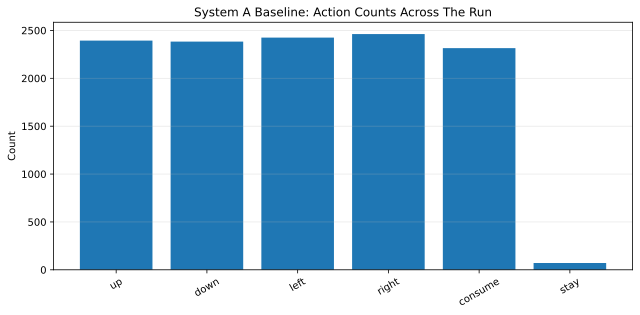

In [17]:
fig, ax = bar_plot(
    action_count_df['action'],
    action_count_df['count'],
    title='System A Baseline: Action Counts Across The Run',
    ylabel='Count',
)


A representative reading of these results is:

- At a 400-step horizon, System A still shows genuine adaptive pressure, but its limits are much clearer than in a shorter run: most episodes eventually deplete energy before the horizon ends.
- Movement dominates the action profile, which matches the fact that hunger has to keep searching locally for consumable opportunity.
- `consume` is substantial but not constant, because current-cell resource is only intermittently available.
- Coverage remains fairly limited and revisit rate stays high, which is exactly what we should expect from a system with no explicit exploration drive or world model.

So the baseline is neither trivial nor sophisticated. It is minimal reactive foraging, and a longer horizon makes both parts of that description easier to see.


## A Representative Trace Moment

To connect the aggregate story back to mechanism, it is useful to inspect one concrete `consume` step from a persisted episode. The example below comes from the current primary baseline run (`$212fb5638cc7498db40e3b94eb4ccaf1$`), `episode_0001`, step `65`.


In [18]:
consume_step = None
consume_step_index = None
for idx, step in enumerate(episode['steps']):
    if step['action'] == 'consume':
        consume_step = step
        consume_step_index = idx
        break

if consume_step is None:
    raise RuntimeError('No consume step found in representative episode.')

consume_decision = consume_step['system_data']['decision_data']
consume_trace = consume_step['system_data']['trace_data']

consume_summary_df = pd.DataFrame(
    [
        ('episode_step', consume_step_index),
        ('action', consume_step['action']),
        ('vitality_before', consume_step['vitality_before']),
        ('vitality_after', consume_step['vitality_after']),
        ('hunger_activation', consume_decision['drive']['activation']),
        ('selected_action', consume_decision['policy']['selected_action']),
        ('energy_before', consume_trace['energy_before']),
        ('energy_after', consume_trace['energy_after']),
        ('energy_gain', consume_trace['energy_gain']),
    ],
    columns=['quantity', 'value'],
)

observation_df = pd.DataFrame(
    [
        ('current', consume_decision['observation']['current']['traversability'], consume_decision['observation']['current']['resource']),
        ('up', consume_decision['observation']['up']['traversability'], consume_decision['observation']['up']['resource']),
        ('down', consume_decision['observation']['down']['traversability'], consume_decision['observation']['down']['resource']),
        ('left', consume_decision['observation']['left']['traversability'], consume_decision['observation']['left']['resource']),
        ('right', consume_decision['observation']['right']['traversability'], consume_decision['observation']['right']['resource']),
    ],
    columns=['direction', 'traversability', 'resource'],
)

policy_df = pd.DataFrame(
    {
        'action': ['up', 'down', 'left', 'right', 'consume', 'stay'],
        'score': consume_decision['drive']['action_contributions'],
        'admissible': consume_decision['policy']['admissibility_mask'],
        'probability': consume_decision['policy']['probabilities'],
    }
)

display(consume_summary_df)
display(observation_df)
display(policy_df)


,quantity,value
0,episode_step,65
1,action,consume
2,vitality_before,0.35
3,vitality_after,0.41
4,hunger_activation,0.65
5,selected_action,consume
6,energy_before,35.0
7,energy_after,41.0
8,energy_gain,6.6


,direction,traversability,resource
0,current,1.0,0.65
1,up,0.0,0.00
2,down,1.0,0.00
3,left,1.0,0.00
4,right,0.0,0.00


,action,score,admissible,probability
0,up,0.00000,False,0.000000
1,down,0.00000,True,0.172039
2,left,0.00000,True,0.172039
3,right,0.00000,False,0.000000
4,consume,1.05625,True,0.494710
5,stay,-0.06500,True,0.161212


This trace moment condenses the whole hunger story into one concrete event.

- Energy is low enough that hunger activation is substantial.
- The current cell contains resource, so the `consume` score becomes strongly positive.
- The selected action follows directly from current local conditions plus homeostatic pressure.
- After the framework applies the action, the transition increases energy.

Notice what is *not* present:

- no search tree
- no remembered target location
- no predicted future patch quality
- no explicit exploration term

The system does something behaviorally useful, but it does it through immediate score shaping rather than planning. The 400-step run does not change that interpretation; it only makes clearer that this mechanism can sustain foraging for a while without becoming robust, long-horizon control.


## Closing Perspective

System A gives AXIS a very important baseline.

It shows that even a single scalar drive, when coupled to local perception and a policy, can already produce structured foraging behavior. But it also makes the limits of that architecture visible:

- behavior is tightly local
- revisitation remains high
- survival is only partial
- no explicit mechanism pushes the system toward exploration beyond what hunger indirectly induces

That simplicity is not a weakness of the notebook. It is the point of System A. Hunger appears here in its most isolated form: as the only drive, directly shaping the entire action-tendency landscape by itself.

Later systems become more interesting precisely because hunger stops being the whole story.

- with **curiosity**, hunger no longer acts alone; it modulates the priority of exploration versus immediate foraging
- with **prediction**, hunger is still not replaced, but its behavioral effect is filtered through a richer decision process in which predictive structure can alter how current options are valued

So this notebook should be read as the baseline case: hunger as a simple drive. In later architectures, the same homeostatic pressure becomes more **modulatory** because it interacts with other drives and with non-drive mechanisms such as prediction.

That is exactly why System A matters. It is the minimal reference point from which later additions such as curiosity, prediction, and world models can be meaningfully interpreted.
